# eTOF time-of-flight to kinetic-energy calibration (config 1)

**Post-analysis task 1** (see `analysis/post/TASKS.md`).

## Objective
Map electron **time-of-flight (TOF)** to electron **kinetic energy (KE)** for the config-1 electron TOF spectrometer. This calibration underpins downstream electron analyses such as peak assignment, residual-gas subtraction, and scan-map interpretation.

## Data
| Role | Run | Notes |
|------|-----|-------|
| Argon calibration | **58826** | known Ar photolines plus LMM Auger lines |
| Residual-gas background | **58825** | subtracted to isolate the Ar signal |

Both inputs are config-1 combined H5 files resolved through `config.COMBINED_DIR`.

## Workflow
1. Set up imports, paths, run IDs, signal bunches, TOF binning, and normalisation.
2. Load the Ar and residual-gas runs, average their eTOF spectra, and subtract the scaled background.
3. Inspect the subtracted spectrum and assign measured TOF peaks to known Ar kinetic energies.
4. Check candidate peak positions, including possible blended lines, before committing to the calibration set.
5. Scan `t0` and fit the linearized model `KE = slope / (tof - t0)**2 + E0`.
6. Estimate fixed-`t0` uncertainties, make diagnostic plots, and apply the calibration to spectra.
7. Save the calibration JSON, then reload it to verify the portable conversion function.


## Setup and Imports

Configure the FLASH environment, add the project analysis scripts to `sys.path`, import the numerical/plotting tools, and define the custom colormap used later for scan maps.


In [2]:
import os, sys
from pathlib import Path

os.environ["FLASH_ENV"] = "remote"

In [3]:
import sys
import json
from pathlib import Path

# analysis/post -> repo root is two levels up (same layout as analysis/notebooks).
cwd = Path.cwd().resolve()
repo_root = Path("/home/mmanresa/glycine26/")

# 2. Safety check to make sure the folder structure is what we expect
scripts_dir = repo_root / "analysis" / "scripts"
if not scripts_dir.exists():
    raise RuntimeError(f"Could not find scripts folder at: {scripts_dir}")

# 3. Add it to Python's path
sys.path.insert(0, str(scripts_dir))

import numpy as np
import matplotlib.pyplot as plt

import config
from data_loading import load_data

try:
    from scipy.signal import find_peaks
    from scipy.optimize import curve_fit
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False
    print("scipy unavailable - peak-finding / nonlinear-fit cells will be skipped.")


import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# Define the custom sequence: White -> Blue -> Red
w_b_r = mcolors.LinearSegmentedColormap.from_list("WhiteBlueRed", ["white", "blue", "red"])

%matplotlib inline

## Calibration Settings

Set the run numbers, input H5 paths, photon energy, signal-bunch window, TOF histogram range, normalisation mode, and residual-gas scale factor. This block also checks that the Ar and background files exist before any heavier processing starts.


In [4]:
# --- Runs --------------------------------------------------------------
RUN_AR = 58826   # Argon calibration
RUN_BG = 58825   # residual-gas background

# Combined-H5 paths. Default to COMBINED_DIR/run<N>.h5; override if needed.
AR_H5 = config.COMBINED_DIR / f"argon_nozzle_in.h5"
BG_H5 = config.COMBINED_DIR / f"glycine_WL_scan_270.0eV.h5"
BG_H5 = config.COMBINED_DIR / f"residual_gas_nozzle_in.h5"

# --- Photon energy of the Argon run (eV) -------------------------------
# REQUIRED for photoline KE = hv - BE. Read from the logbook / mpe.
PHOTON_ENERGY_EV = 270   # e.g. 285.0

# --- Signal bunch range (half-open) ------------------------------------
# Determine from the diagnostics notebook for these runs.
SIGNAL_BUNCH_RANGE = (10, 40)

# --- TOF histogram binning (ns) ----------------------------------------
# Span the eTOF window; refine after a first look at the spectrum.
TOF_MIN, TOF_MAX, TOF_BIN = 0.0, 4000.0, 1.0
tof_edges = np.arange(TOF_MIN, TOF_MAX + TOF_BIN, TOF_BIN)
tof_cent  = 0.5 * (tof_edges[:-1] + tof_edges[1:])

# --- Normalisation -----------------------------------------------------
# "per_shot": counts per (train, bunch) shot.
# "per_uJ"  : counts per shot per uJ of GMD (fluence-normalised).
NORMALISE = "per_shot"

# --- Background scaling -------------------------------------------------
# Residual-gas pressure may differ between runs; tune if the subtraction
# over/under-shoots in a known-empty TOF region.
BG_SCALE = 1.0

# --- Resolve / check ---------------------------------------------------
for label, p in [("Ar", AR_H5), ("background", BG_H5)]:
    if not Path(p).exists():
        raise FileNotFoundError(
            f"{label} combined H5 not found: {p}\n"
            f"Build it with write_h5.py (config 1) or set the path above."
        )
print(f"Ar run {RUN_AR}: {AR_H5}")
print(f"BG run {RUN_BG}: {BG_H5}")
print(f"signal bunches [{SIGNAL_BUNCH_RANGE[0]}, {SIGNAL_BUNCH_RANGE[1]}), "
      f"TOF [{TOF_MIN}, {TOF_MAX}] ns / {TOF_BIN} ns bins, normalise={NORMALISE}")

Ar run 58826: /asap3/flash/gpfs/fl24/2026/data/11022188/processed/combined/argon_nozzle_in.h5
BG run 58825: /asap3/flash/gpfs/fl24/2026/data/11022188/processed/combined/residual_gas_nozzle_in.h5
signal bunches [10, 40), TOF [0.0, 4000.0] ns / 1.0 ns bins, normalise=per_shot


## Load Calibration and Background Runs

Load the Ar calibration data and residual-gas background with `load_data(..., config=1)`. The checks here confirm that both files contain electron TOF arrays and that the selected signal-bunch range is valid for each run.


In [5]:
b0, b1 = SIGNAL_BUNCH_RANGE

ar = load_data(str(AR_H5), config=1)
bg = load_data(str(BG_H5), config=1)

for name, d in [("Ar", ar), ("background", bg)]:
    if d.tofs_e is None:
        raise RuntimeError(f"{name} run has no tofs_e - is it a config-1 file?")
    print(f"{name:>10}: n_trains={d.n_trains}, m={d.n_bunches}, "
          f"max_ecounts={d.tofs_e.shape[-1]}")
    if not (0 <= b0 < b1 <= d.n_bunches):
        raise ValueError(
            f"{name}: SIGNAL_BUNCH_RANGE {SIGNAL_BUNCH_RANGE} outside [0, {d.n_bunches}]"
        )

        Ar: n_trains=3001, m=101, max_ecounts=50
background: n_trains=3001, m=101, max_ecounts=50


## Average eTOF Spectra

eTOF arrays are zero-padded, so real hits are the non-zero values. This block slices the selected bunches, histograms all valid hits in one pass, and normalises the Ar and residual-gas spectra onto the same scale.


In [6]:
def average_etof(data, bunch_range, edges, normalise="per_shot"):
    """Average eTOF spectrum over a signal bunch range.

    Excludes zero-padding, histograms all hits in a single pass, and
    normalises so spectra from different runs are comparable.
    Returns (spectrum, n_shots, total_gmd).
    """
    lo, hi = bunch_range
    hits = data.tofs_e[:, lo:hi, :]            # (n_trains, n_sig, max_hits)
    n_shots = hits.shape[0] * hits.shape[1]    # number of (train, bunch) shots
    valid = hits[hits > 0]                     # drop zero-padding
    counts, _ = np.histogram(valid, bins=edges)
    counts = counts.astype(np.float64)

    gmd_sig = np.asarray(data.gmd[:, lo:hi], dtype=np.float64)
    total_gmd = np.nansum(gmd_sig)

    if normalise == "per_shot":
        spectrum = counts / max(n_shots, 1)
    elif normalise == "per_uJ":
        spectrum = counts / total_gmd if total_gmd > 0 else counts
    else:
        raise ValueError(f"unknown NORMALISE={normalise!r}")
    return spectrum, n_shots, total_gmd

ar_spec, ar_n, ar_g = average_etof(ar, SIGNAL_BUNCH_RANGE, tof_edges, NORMALISE)
bg_spec, bg_n, bg_g = average_etof(bg, SIGNAL_BUNCH_RANGE, tof_edges, NORMALISE)

print(f"Ar: {ar_n} shots, total GMD {ar_g:.3g} uJ")
print(f"BG: {bg_n} shots, total GMD {bg_g:.3g} uJ")

Ar: 90030 shots, total GMD 5.72e+05 uJ
BG: 90030 shots, total GMD 5.97e+05 uJ


## Subtract Residual-Gas Background

Subtract the scaled residual-gas spectrum from the Ar spectrum and plot both the raw comparison and the background-subtracted result. Use this plot to tune `BG_SCALE` and identify clear calibration peaks.


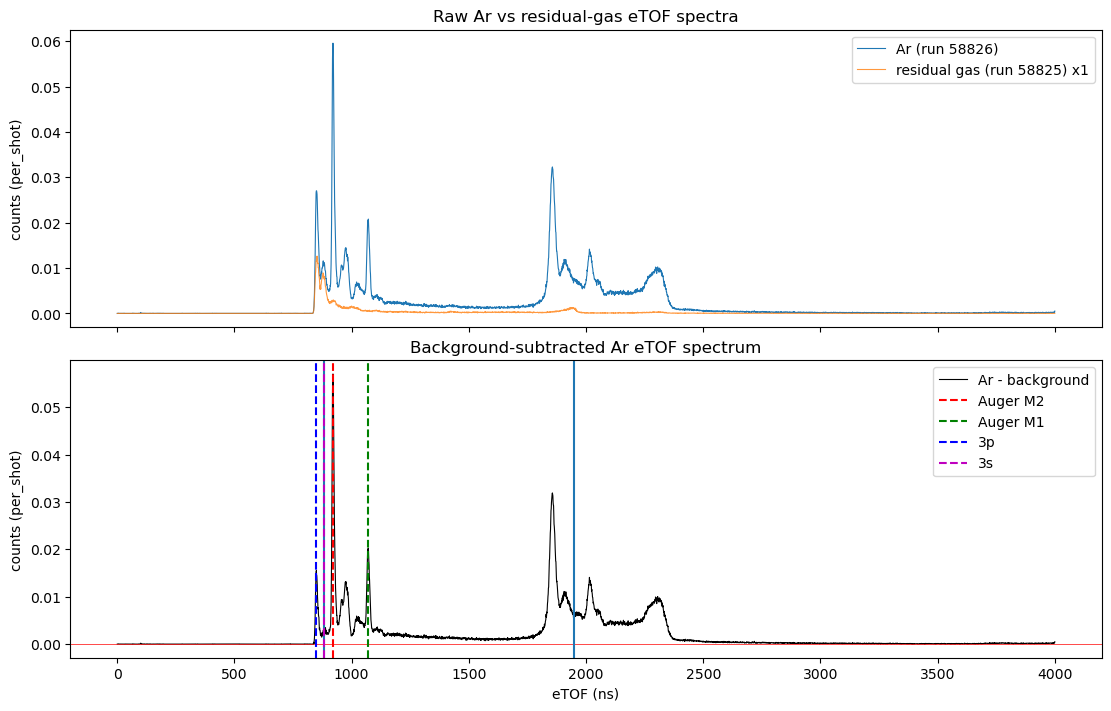

In [7]:
ar_sub = ar_spec - BG_SCALE * bg_spec

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               constrained_layout=True)
ax1.plot(tof_cent, ar_spec, lw=0.8, label=f"Ar (run {RUN_AR})")
ax1.plot(tof_cent, BG_SCALE * bg_spec, lw=0.8, alpha=0.8,
         label=f"residual gas (run {RUN_BG}) x{BG_SCALE:g}")
ax1.set_ylabel(f"counts ({NORMALISE})")
ax1.legend(); ax1.set_title("Raw Ar vs residual-gas eTOF spectra")

ax2.plot(tof_cent, ar_sub, lw=0.8, color="k", label="Ar - background")
ax2.axhline(0, color="r", lw=0.5)
ax2.set_xlabel("eTOF (ns)"); ax2.set_ylabel(f"counts ({NORMALISE})")
ax2.legend(); ax2.set_title("Background-subtracted Ar eTOF spectrum")
ax2.axvline(883)

ax2.axvline(x=920.5, color='r', linestyle='--', label='Auger M2')
ax2.axvline(x=1071.5, color='g', linestyle='--', label='Auger M1')
ax2.axvline(x=850, color='b', linestyle='--', label='3p')
ax2.axvline(x=883, color='m', linestyle='--', label='3s')

ax2.legend()
ax2.axvline(1950)
# ax2.set_xlim(750,1200)
# ax2.set_xlim(750,1200)
plt.show()

## Peak Finding and Draft Line Assignments

Use the background-subtracted spectrum to identify candidate TOF peaks, then assign them to known Ar lines. Photoline kinetic energies depend on photon energy via `KE = hv - BE`; LMM Auger lines have fixed kinetic energies and are useful anchors because they do not move with `hv`.

Reference binding energies for common Ar photolines:

| line | BE (eV) |
|------|---------|
| Ar 2p3/2 | 248.4 |
| Ar 2p1/2 | 250.6 |
| Ar 3s | 29.24 |
| Ar 3p | 15.76 |

The assignments made here are an initial/manual calibration set; later cells refine the active `ASSIGNMENTS` used by the t0-scan fit.


In [8]:
# Suggest candidate peaks (tune prominence to the data).
if _HAVE_SCIPY:
    pk, props = find_peaks(ar_sub, prominence=np.nanmax(ar_sub) * 0.02)
    order = np.argsort(props["prominences"])[::-1]
    print("candidate peaks (most prominent first):")
    print(f"{'TOF (ns)':>10} {'counts':>12} {'prominence':>12}")
    for i in order[:25]:
        print(f"{tof_cent[pk[i]]:>10.2f} {ar_sub[pk[i]]:>12.4g} "
              f"{props['prominences'][i]:>12.4g}")
else:
    print("scipy unavailable - read peak TOFs off the plot manually.")

def photoline_ke(be_eV):
    """KE of an Ar photoline of binding energy be_eV at PHOTON_ENERGY_EV."""
    if PHOTON_ENERGY_EV is None:
        raise ValueError("set PHOTON_ENERGY_EV to use photoline_ke()")
    return PHOTON_ENERGY_EV - be_eV

# --- FILL IN after inspecting the spectrum ----------------------------
# Each entry: (tof_peak_ns, known_KE_eV, label). Example (edit & uncomment):
ASSIGNMENTS = [
    # (1855, photoline_ke(248.4), "Ar 2p3/2"),
    # (1910, photoline_ke(250.6), "Ar 2p1/2")
    # (XXX.X, 203.0,               "Ar LMM (1D2)"),
]
ASSIGNMENTS = [

    # Option 1
    # (850, 254.2, '3p'),
    # (920.5, 240.7, '3s'), 
    # (1856.5, 20, '2p')

    #Option 2
    # (920.5, 254.2, '3p'), 
    # (1071.5, 240.7, '3s'),
    # (1856.5, 20, '2p')

    # Option 3: Auger
    (920.5, 207, 'Auger M2'), 
    (1071.5, 147, 'Auger M1'),
    (850, 253.4, '3p'), #.8 lower than actually
    # (883, 240.7, '3s'),
    #(1856, 28, '2p')
    
    # (975, 178, 'Auger intermediate')
    # (1856.5, 25, '2p')
    #Try with the lowest peak too

    
]
assert len(ASSIGNMENTS) >= 2, (
    "need at least 2 (TOF, KE) pairs to fit; 3+ recommended for a residual check"
)

candidate peaks (most prominent first):
  TOF (ns)       counts   prominence
    920.50        0.057        0.057
   1856.50       0.0319       0.0312
   1071.50      0.02025      0.01853
    849.50      0.01552      0.01404
    975.50      0.01318     0.009175
   2014.50      0.01408     0.008853
   2305.50      0.01003     0.006165
   1906.50      0.01111     0.003388
   1021.50      0.00592     0.002421
    883.50     0.003588     0.001555
   2296.50     0.009941       0.0014
   2050.50     0.007398     0.001311
   1960.50     0.006809       0.0012
    956.50     0.009397       0.0012


## Inspect Peaks for the t0-Scan Calibration

Replot the Ar and background-subtracted spectra with visual markers on the candidate calibration lines. This is the working inspection step before choosing the final TOF/KE pairs for the t0 scan.


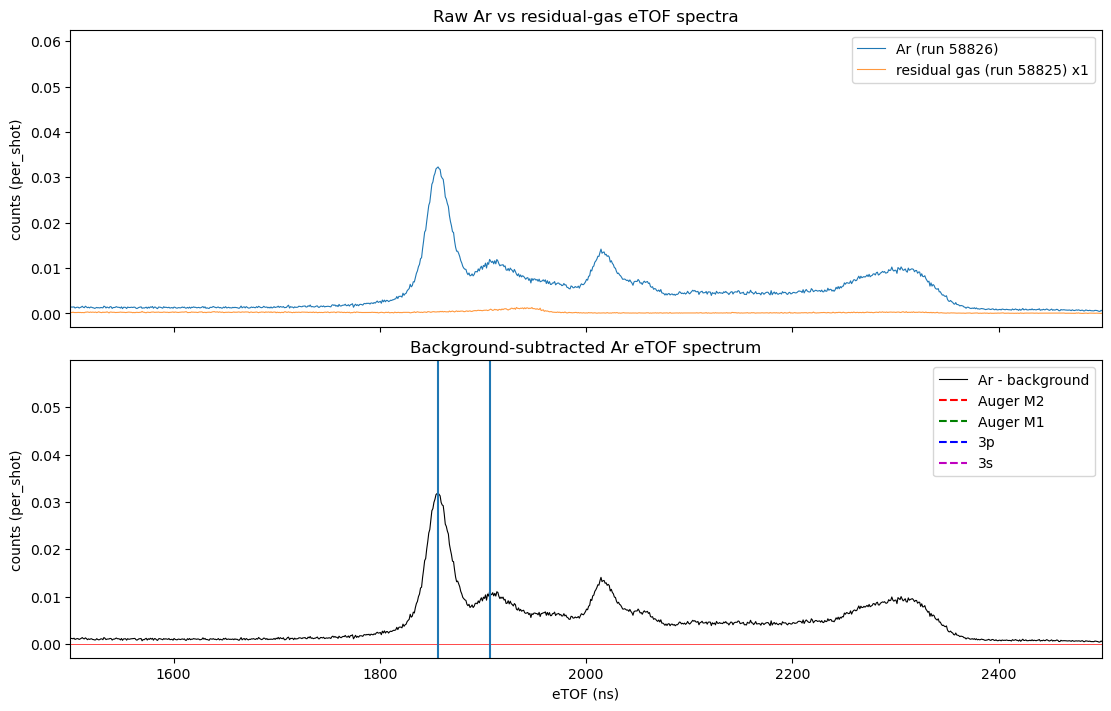

In [10]:
ar_sub = ar_spec - BG_SCALE * bg_spec

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               constrained_layout=True)
ax1.plot(tof_cent, ar_spec, lw=0.8, label=f"Ar (run {RUN_AR})")
ax1.plot(tof_cent, BG_SCALE * bg_spec, lw=0.8, alpha=0.8,
         label=f"residual gas (run {RUN_BG}) x{BG_SCALE:g}")
ax1.set_ylabel(f"counts ({NORMALISE})")
ax1.legend(); ax1.set_title("Raw Ar vs residual-gas eTOF spectra")

ax2.plot(tof_cent, ar_sub, lw=0.8, color="k", label="Ar - background")
ax2.axhline(0, color="r", lw=0.5)
ax2.set_xlabel("eTOF (ns)"); ax2.set_ylabel(f"counts ({NORMALISE})")
ax2.legend(); ax2.set_title("Background-subtracted Ar eTOF spectrum")
ax2.axvline(883)

ax2.axvline(x=920.5, color='r', linestyle='--', label='Auger M2')
ax2.axvline(x=1071.5, color='g', linestyle='--', label='Auger M1')
ax2.axvline(x=850, color='b', linestyle='--', label='3p')
ax2.axvline(x=883, color='m', linestyle='--', label='3s')

ax2.legend()
ax2.axvline(1856.5)
ax2.axvline(1906.5)

# ax2.set_xlim(750,1200)
# ax2.set_xlim(750,1200)
ax2.set_xlim(1500,2500)
plt.show()

## Find centroid position for a broad Auger line

Fit the selected target peak locally with single- and double-Gaussian models. This checks whether the assigned TOF should be the tallest bin or a centroid when nearby structure is blended.


Target: Auger L₃–M₂,₃M₂,₃ ¹D₂
Assigned TOF: 921.8000
Known KE:      204.5000 eV

Single Gaussian:
  mu     = 921.0058
  sigma  = 4.2250
  shift from assigned = -0.7942 TOF units
  RSS    = 0.000582886
  AIC    = -938.364

Double Gaussian:
  mu1    = 919.8442, sigma1 = 3.3058, amp1 = 0.04464
  mu2    = 925.3842, sigma2 = 4.8949, amp2 = 0.01701
  area-weighted centroid = 921.8423
  centroid shift from assigned = +0.0423 TOF units
  RSS    = 0.000308777
  AIC    = -983.193

ΔAIC = AIC_single - AIC_double = 44.830
Positive ΔAIC means the double-Gaussian fit is preferred.


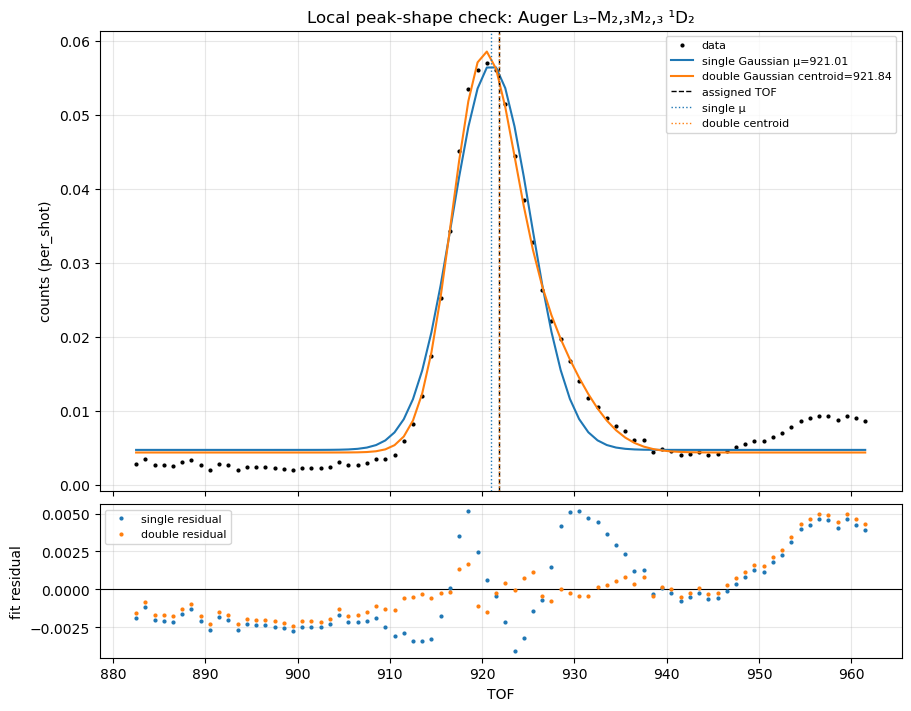

In [13]:
# Check whether one calibration peak is blended or whether the picked TOF
# should be a centroid rather than the tallest bin.

from scipy.optimize import curve_fit

TARGET_LABEL = "Auger L₃–M₂,₃M₂,₃ ¹D₂"

WINDOW = 40.0   # TOF units around assigned peak
FIT_BACKGROUND = True

# Use the background-subtracted spectrum from the calibration notebook.
# If you want raw Ar instead, replace ar_sub with ar_spec.
y_full = ar_sub
x_full = tof_cent

# Find assigned TOF/KE for target line.
matches = [(t, ke, lbl) for t, ke, lbl in ASSIGNMENTS if lbl == TARGET_LABEL]

if len(matches) != 1:
    raise ValueError(f"Found {len(matches)} matches for TARGET_LABEL={TARGET_LABEL!r}")

t_guess, ke_known_target, lbl = matches[0]

mask = (
    (x_full >= t_guess - WINDOW)
    & (x_full <= t_guess + WINDOW)
    & np.isfinite(y_full)
)

x = x_full[mask]
y = y_full[mask]

if x.size < 10:
    raise RuntimeError("Too few points in peak window. Increase WINDOW or check TARGET_LABEL.")

# Local baseline estimate.
baseline_guess = np.nanpercentile(y, 10)
amp_guess = np.nanmax(y) - baseline_guess
mu_guess = x[np.nanargmax(y)]
sigma_guess = 5.0


def gaussian(x, amp, mu, sigma, c):
    return c + amp * np.exp(-0.5 * ((x - mu) / sigma)**2)


def double_gaussian_shared_bg(x, amp1, mu1, sigma1, amp2, mu2, sigma2, c):
    return (
        c
        + amp1 * np.exp(-0.5 * ((x - mu1) / sigma1)**2)
        + amp2 * np.exp(-0.5 * ((x - mu2) / sigma2)**2)
    )


# Single Gaussian fit.
p0_single = [amp_guess, mu_guess, sigma_guess, baseline_guess]

bounds_single = (
    [0, t_guess - WINDOW, 0.5, -np.inf],
    [np.inf, t_guess + WINDOW, WINDOW, np.inf],
)

popt_single, pcov_single = curve_fit(
    gaussian,
    x,
    y,
    p0=p0_single,
    bounds=bounds_single,
    maxfev=20000,
)

y_single = gaussian(x, *popt_single)
res_single = y - y_single
rss_single = np.sum(res_single**2)

amp_s, mu_s, sigma_s, c_s = popt_single

# Double Gaussian fit.
# Initial guesses: split around the original max.
p0_double = [
    amp_guess * 0.6,
    t_guess - 3.0,
    sigma_guess,
    amp_guess * 0.4,
    t_guess + 3.0,
    sigma_guess,
    baseline_guess,
]

bounds_double = (
    [0, t_guess - WINDOW, 0.5, 0, t_guess - WINDOW, 0.5, -np.inf],
    [np.inf, t_guess + WINDOW, WINDOW, np.inf, t_guess + WINDOW, WINDOW, np.inf],
)

popt_double, pcov_double = curve_fit(
    double_gaussian_shared_bg,
    x,
    y,
    p0=p0_double,
    bounds=bounds_double,
    maxfev=50000,
)

# Sort components by center.
amp1, mu1, sig1, amp2, mu2, sig2, c_d = popt_double

if mu2 < mu1:
    amp1, amp2 = amp2, amp1
    mu1, mu2 = mu2, mu1
    sig1, sig2 = sig2, sig1

popt_double_sorted = [amp1, mu1, sig1, amp2, mu2, sig2, c_d]

y_double = double_gaussian_shared_bg(x, *popt_double_sorted)
res_double = y - y_double
rss_double = np.sum(res_double**2)

# AIC comparison: lower is better.
n = x.size
k_single = 4
k_double = 7

aic_single = n * np.log(rss_single / n) + 2 * k_single
aic_double = n * np.log(rss_double / n) + 2 * k_double

# Area-weighted centroid of the two-Gaussian model.
area1 = amp1 * abs(sig1)
area2 = amp2 * abs(sig2)
mu_double_centroid = (area1 * mu1 + area2 * mu2) / (area1 + area2)

print(f"Target: {lbl}")
print(f"Assigned TOF: {t_guess:.4f}")
print(f"Known KE:      {ke_known_target:.4f} eV")
print()
print("Single Gaussian:")
print(f"  mu     = {mu_s:.4f}")
print(f"  sigma  = {sigma_s:.4f}")
print(f"  shift from assigned = {mu_s - t_guess:+.4f} TOF units")
print(f"  RSS    = {rss_single:.6g}")
print(f"  AIC    = {aic_single:.3f}")
print()
print("Double Gaussian:")
print(f"  mu1    = {mu1:.4f}, sigma1 = {sig1:.4f}, amp1 = {amp1:.4g}")
print(f"  mu2    = {mu2:.4f}, sigma2 = {sig2:.4f}, amp2 = {amp2:.4g}")
print(f"  area-weighted centroid = {mu_double_centroid:.4f}")
print(f"  centroid shift from assigned = {mu_double_centroid - t_guess:+.4f} TOF units")
print(f"  RSS    = {rss_double:.6g}")
print(f"  AIC    = {aic_double:.3f}")
print()
print(f"ΔAIC = AIC_single - AIC_double = {aic_single - aic_double:.3f}")
print("Positive ΔAIC means the double-Gaussian fit is preferred.")


fig, (ax0, ax1) = plt.subplots(
    2, 1,
    figsize=(9, 7),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

ax0.plot(x, y, "k.", ms=4, label="data")
ax0.plot(x, y_single, "-", lw=1.5, label=f"single Gaussian μ={mu_s:.2f}")
ax0.plot(x, y_double, "-", lw=1.5, label=f"double Gaussian centroid={mu_double_centroid:.2f}")

ax0.axvline(t_guess, color="k", ls="--", lw=1, label="assigned TOF")
ax0.axvline(mu_s, color="tab:blue", ls=":", lw=1, label="single μ")
ax0.axvline(mu_double_centroid, color="tab:orange", ls=":", lw=1, label="double centroid")

ax0.set_ylabel(f"counts ({NORMALISE})")
ax0.set_title(f"Local peak-shape check: {lbl}")
ax0.grid(alpha=0.3)
ax0.legend(fontsize=8)

ax1.axhline(0, color="k", lw=0.8)
ax1.plot(x, res_single, ".", ms=4, label="single residual")
ax1.plot(x, res_double, ".", ms=4, label="double residual")
ax1.set_xlabel("TOF")
ax1.set_ylabel("fit residual")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=8)

plt.show()

## Final Calibration-Line Assignments

Define the active `(TOF, known KE, label)` pairs used by the t0-scan calibration. The commented alternatives document trial assignment sets; the uncommented entries are the fit inputs.


In [1]:
ASSIGNMENTS = [

    (849.5,  253.4, 'Ar 3p photoelectron'),
    (921.8, 204.5, 'Auger L₃–M₂,₃M₂,₃ ¹D₂'),
    (975, 178, 'Auger L₃–M₁M₁ ¹D₂'),
    (1071.5, 142, 'Auger L₃–M₁M₁ ¹P₁'),
    (1856.5, 21.6, 'Ar 2p_(3/2) photoelectron'),
    (1907.5, 19.4, 'Ar 2p_(1/2) photoelectron')



    
]

## Scan t0 and Fit the Linearized Calibration

Scan possible `t0` values and, for each candidate, fit `KE = slope * x + E0` with `x = 1 / (tof - t0)**2`. The best scan point defines the calibration parameters and the reusable `KE_from_TOF` function.


In [14]:
# Outer-scan t0 calibration:
#   KE = slope * x + E0
#   x = 1 / (t - t0)^2
#
# This avoids fitting t0 nonlinearly together with the other parameters.

asg = np.array([(t, ke) for t, ke, _ in ASSIGNMENTS], dtype=float)
t_peaks = asg[:, 0]
ke_known = asg[:, 1]
labels = [lbl for _, _, lbl in ASSIGNMENTS]

if len(ASSIGNMENTS) < 2:
    raise ValueError("Need at least 2 calibration peaks.")

if len(ASSIGNMENTS) == 2:
    print("WARNING: only 2 peaks provided.")
    print("Every t0 gives an exact line through 2 points, so the t0 scan is under-constrained.")
    print("Use 3+ peaks if you want this scan to actually select t0.")

# IMPORTANT:
# Raw eTOF times in these files appear to be in 100 ps units.
# If your t_peaks are genuinely in ns, change this to 1e-9.
TOF_UNIT_SECONDS = 100e-12

m_e = 9.1093837015e-31
e_charge = 1.602176634e-19

T0_SCAN_STEPS = 1000
t0_min = -500.0
t0_max = np.min(t_peaks) * 0.8

t0_scan = np.linspace(t0_min, t0_max, T0_SCAN_STEPS)

r2_scan = np.full_like(t0_scan, np.nan, dtype=float)
rmse_scan = np.full_like(t0_scan, np.nan, dtype=float)
slope_scan = np.full_like(t0_scan, np.nan, dtype=float)
E0_scan = np.full_like(t0_scan, np.nan, dtype=float)

for i, t0_cand in enumerate(t0_scan):
    dt = t_peaks - t0_cand

    if np.any(dt <= 0):
        continue

    x = 1.0 / dt**2

    slope, E0 = np.polyfit(x, ke_known, deg=1)




# E0_FIXED = 10.0  # eV — from Uret = -10 V
# # Replace the E0 warning check with:
# print(f"  E0 fixed at {E0_FIXED:.1f} eV (from Uret = -10 V)")

# for i, t0_cand in enumerate(t0_scan):
#     dt = t_peaks - t0_cand
#     if np.any(dt <= 0):
#         continue
#     x = 1.0 / dt**2
#     y = ke_known - E0_FIXED          # subtract known offset
#     slope = np.dot(x, y) / np.dot(x, x)   # least-squares slope through origin
#     E0 = E0_FIXED       

    #End of fixed E0 code block

    ke_pred = slope * x + E0

    resid = ke_known - ke_pred
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((ke_known - np.mean(ke_known))**2)

    if ss_tot > 0:
        r2 = 1.0 - ss_res / ss_tot
    else:
        r2 = np.nan

    r2_scan[i] = r2
    rmse_scan[i] = np.sqrt(np.mean(resid**2))
    slope_scan[i] = slope
    E0_scan[i] = E0

best_idx = np.nanargmax(r2_scan)

best_t0 = t0_scan[best_idx]
best_slope = slope_scan[best_idx]
best_E0 = E0_scan[best_idx]
best_r2 = r2_scan[best_idx]
best_rmse = rmse_scan[best_idx]

x_best = 1.0 / (t_peaks - best_t0)**2
ke_pred_best = best_slope * x_best + best_E0
resid_best = ke_known - ke_pred_best

if best_slope > 0:
    L_fitted_m = TOF_UNIT_SECONDS * np.sqrt(2 * e_charge * best_slope / m_e)
    L_fitted_mm = L_fitted_m * 1000
else:
    L_fitted_m = np.nan
    L_fitted_mm = np.nan

print("Best outer-scan calibration:")
print(f"  t0       = {best_t0:.6f} TOF units")
print(f"  slope a  = {best_slope:.6e} eV * TOF_unit^2")
print(f"  E0       = {best_E0:.6f} eV")
print(f"  L fitted = {L_fitted_mm:.2f} mm")
print(f"  R^2      = {best_r2:.8f}")
print(f"  RMSE     = {best_rmse:.6f} eV")

print()
print("Sanity checks:")

if not np.all(best_t0 < t_peaks):
    print("  WARNING: t0 is not strictly less than all peak TOFs.")
else:
    print("  OK: t0 is less than all peak TOFs.")

if not (0 <= best_E0 <= 30):
    print(f"  WARNING: E0 = {best_E0:.3f} eV is outside expected 0–30 eV.")
else:
    print("  OK: E0 is in expected 0–30 eV range.")

if not (700 <= L_fitted_mm <= 800):
    print(f"  WARNING: fitted length = {L_fitted_mm:.1f} mm, outside expected 700–800 mm.")
else:
    print("  OK: fitted length is in expected 700–800 mm range.")

print()
print("Residuals table:")
print(f"{'label':>18} {'known KE / eV':>15} {'pred KE / eV':>15} {'diff / eV':>12}")
for lbl, ke, pred, diff in zip(labels, ke_known, ke_pred_best, resid_best):
    print(f"{lbl:>18} {ke:15.4f} {pred:15.4f} {diff:12.4f}")


def KE_from_TOF(t):
    """
    Convert TOF to electron kinetic energy using the best t0-scan calibration.

    KE = slope / (t - t0)^2 + E0
    """
    t = np.asarray(t, dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        ke = best_slope / (t - best_t0)**2 + best_E0

    return np.where(t > best_t0, ke, np.nan)


# Optional compatibility with the rest of the notebook:
tof_to_ke = KE_from_TOF

Best outer-scan calibration:
  t0       = 70.317117 TOF units
  slope a  = 1.726561e+08 eV * TOF_unit^2
  E0       = -32.015747 eV
  L fitted = 779.32 mm
  R^2      = 0.99982907
  RMSE     = 1.156586 eV

Sanity checks:
  OK: t0 is less than all peak TOFs.
  OK: fitted length is in expected 700–800 mm range.

Residuals table:
             label   known KE / eV    pred KE / eV    diff / eV
Ar 3p photoelectron        253.4000        252.3668       1.0332
Auger L₃–M₂,₃M₂,₃ ¹D₂        204.5000        206.1230      -1.6230
 Auger L₃–M₁M₁ ¹D₂        178.0000        178.9389      -0.9389
 Auger L₃–M₁M₁ ¹P₁        142.0000        140.2326       1.7674
Ar 2p_(3/2) photoelectron         21.6000         22.1008      -0.5008
Ar 2p_(1/2) photoelectron         19.4000         19.1380       0.2620


## Estimate Fixed-t0 Fit Uncertainty

With `best_t0` fixed, refit the linear model and estimate 95% confidence intervals for the slope, `E0`, and effective flight length. These uncertainty values are later included in the saved JSON when available.


In [15]:
# 95% confidence band for the final linearized calibration
# at the selected best_t0.
#
# Model:
#   KE = slope * x + E0
#   x = 1 / (TOF - best_t0)^2

from scipy.stats import t as student_t

# Calibration points
asg = np.array([(tof, ke) for tof, ke, _ in ASSIGNMENTS], dtype=float)
t_peaks = asg[:, 0]
ke_known = asg[:, 1]
labels = [lbl for _, _, lbl in ASSIGNMENTS]

# Use the best t0 from the outer scan
x = 1.0 / (t_peaks - best_t0)**2
y = ke_known

n = len(x)
p = 2  # slope + intercept
dof = n - p

if dof <= 0:
    raise RuntimeError("Need at least 3 calibration points to estimate confidence bounds.")

# Linear fit at fixed best_t0
best_slope, best_E0 = np.polyfit(x, y, deg=1)

y_fit = best_slope * x + best_E0
resid = y - y_fit

sse = np.sum(resid**2)
mse = sse / dof
s_err = np.sqrt(mse)

x_mean = np.mean(x)
Sxx = np.sum((x - x_mean)**2)

# Parameter uncertainties
slope_se = s_err / np.sqrt(Sxx)
E0_se = s_err * np.sqrt(1.0 / n + x_mean**2 / Sxx)

tcrit = student_t.ppf(0.975, dof)

slope_ci95 = tcrit * slope_se
E0_ci95 = tcrit * E0_se

# Effective bottle length from slope
TOF_UNIT_SECONDS = 100e-12
m_e = 9.1093837015e-31
e_charge = 1.602176634e-19

L_mm = TOF_UNIT_SECONDS * np.sqrt(2 * e_charge * best_slope / m_e) * 1000

# Propagate slope uncertainty into L.
# Since L ∝ sqrt(slope), dL/L = 0.5 * dslope/slope.
L_se_mm = L_mm * 0.5 * slope_se / best_slope
L_ci95_mm = tcrit * L_se_mm

print("Linearized calibration uncertainty at fixed best_t0:")
print(f"  best_t0 = {best_t0:.6f} TOF units")
print(f"  slope   = {best_slope:.6e} ± {slope_ci95:.6e} eV * TOF_unit^2  (95% CI)")
print(f"  E0      = {best_E0:.3f} ± {E0_ci95:.3f} eV  (95% CI)")
print(f"  L       = {L_mm:.1f} ± {L_ci95_mm:.1f} mm  (95% CI)")
print(f"  RMSE    = {np.sqrt(mse):.3f} eV")
print(f"  dof     = {dof}")

Linearized calibration uncertainty at fixed best_t0:
  best_t0 = 70.317117 TOF units
  slope   = 1.726561e+08 ± 3.133890e+06 eV * TOF_unit^2  (95% CI)
  E0      = -32.016 ± 3.454 eV  (95% CI)
  L       = 779.3 ± 7.1 mm  (95% CI)
  RMSE    = 1.417 eV
  dof     = 4


## Plot Calibration Fit and Residuals

Make diagnostic plots for the selected `t0`: the scan quality, the linearized KE fit, the confidence band, and the residuals of the assigned calibration lines.


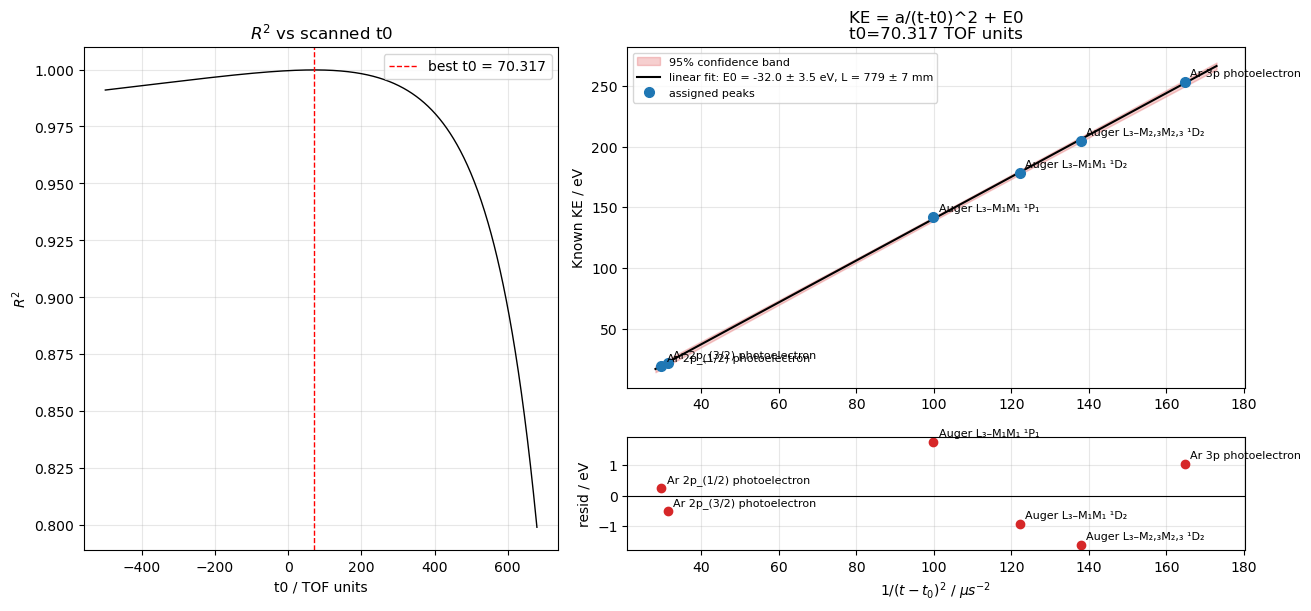

95% confidence estimates at fixed best_t0:
  E0 = -32.016 ± 3.454 eV
  L  = 779.32 ± 7.07 mm
  RMSE = 1.157 eV
  fit standard error = 1.417 eV
  degrees of freedom = 4


In [16]:
# Diagnostic plot:
# left: R^2 vs t0
# right: KE vs x with 95% confidence band and residuals below
#
# x-axis is shown as 1 / (TOF - t0)^2 in 1/us^2,
# matching the thesis-style convention.

from scipy.stats import t as student_t

# Unit conversion.
# Raw TOF units appear to be 100 ps.
# 100 ps = 1e-4 us.
TOF_UNIT_US = 1e-4

# Recompute x in thesis-style units: 1/us^2.
dt_us = (t_peaks - best_t0) * TOF_UNIT_US
x_best_us = 1.0 / dt_us**2

# Fit KE = slope_us * x_us + E0 at fixed best_t0.
# This is the same fit as before, just with x in 1/us^2.
best_slope_us, best_E0_us = np.polyfit(x_best_us, ke_known, deg=1)

ke_pred_us = best_slope_us * x_best_us + best_E0_us
resid_us = ke_known - ke_pred_us

n = len(x_best_us)
p = 2
dof = n - p

if dof <= 0:
    raise RuntimeError("Need at least 3 calibration points to compute confidence bounds.")

sse = np.sum(resid_us**2)
mse = sse / dof
s_err = np.sqrt(mse)

x_mean = np.mean(x_best_us)
Sxx = np.sum((x_best_us - x_mean)**2)

tcrit = student_t.ppf(0.975, dof)

# Parameter standard errors and 95% intervals.
slope_se_us = s_err / np.sqrt(Sxx)
E0_se_us = s_err * np.sqrt(1.0 / n + x_mean**2 / Sxx)

slope_ci95_us = tcrit * slope_se_us
E0_ci95_us = tcrit * E0_se_us

# Convert slope to effective length.
#
# If x is 1/us^2:
#   KE[eV] = slope_us / dt_us^2 + E0
# and:
#   L = 1e-6 * sqrt(2 * e * slope_us / m_e)
m_e = 9.1093837015e-31
e_charge = 1.602176634e-19

L_fitted_m_us = 1e-6 * np.sqrt(2 * e_charge * best_slope_us / m_e)
L_fitted_mm_us = L_fitted_m_us * 1000

# Since L ∝ sqrt(slope), dL/L = 0.5 dslope/slope.
L_se_mm_us = L_fitted_mm_us * 0.5 * slope_se_us / best_slope_us
L_ci95_mm_us = tcrit * L_se_mm_us

# Line and confidence band.
x_line_us = np.linspace(x_best_us.min() * 0.95, x_best_us.max() * 1.05, 500)
ke_line_us = best_slope_us * x_line_us + best_E0_us

# 95% confidence interval for the mean fitted line.
ci_mean = tcrit * s_err * np.sqrt(
    1.0 / n + (x_line_us - x_mean)**2 / Sxx
)

ke_lower = ke_line_us - ci_mean
ke_upper = ke_line_us + ci_mean


fig = plt.figure(figsize=(13, 6), constrained_layout=True)
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.0, 1.3],
    height_ratios=[3, 1],
)

ax_r2 = fig.add_subplot(gs[:, 0])
ax_fit = fig.add_subplot(gs[0, 1])
ax_res = fig.add_subplot(gs[1, 1], sharex=ax_fit)

# Panel 1: R^2 scan
ax_r2.plot(t0_scan, r2_scan, color="k", lw=1)
ax_r2.axvline(
    best_t0,
    color="r",
    ls="--",
    lw=1,
    label=f"best t0 = {best_t0:.3f}",
)

ax_r2.set_xlabel("t0 / TOF units")
ax_r2.set_ylabel(r"$R^2$")
ax_r2.set_title(r"$R^2$ vs scanned t0")
ax_r2.grid(alpha=0.3)
ax_r2.legend()

# Panel 2: linearized KE fit with 95% confidence band
ax_fit.fill_between(
    x_line_us,
    ke_lower,
    ke_upper,
    color="tab:red",
    alpha=0.22,
    label="95% confidence band",
)

ax_fit.plot(
    x_line_us,
    ke_line_us,
    "-",
    color="k",
    lw=1.5,
    label=(
        f"linear fit: "
        f"E0 = {best_E0_us:.1f} ± {E0_ci95_us:.1f} eV, "
        f"L = {L_fitted_mm_us:.0f} ± {L_ci95_mm_us:.0f} mm"
    ),
)

ax_fit.plot(
    x_best_us,
    ke_known,
    "o",
    ms=7,
    label="assigned peaks",
)

for x, ke, lbl in zip(x_best_us, ke_known, labels):
    ax_fit.annotate(
        lbl,
        (x, ke),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax_fit.set_ylabel("Known KE / eV")
ax_fit.set_title(
    f"KE = a/(t-t0)^2 + E0\n"
    f"t0={best_t0:.3f} TOF units"
)
ax_fit.grid(alpha=0.3)
ax_fit.legend(fontsize=8)

# Residuals
ax_res.axhline(0, color="k", lw=0.8)
ax_res.plot(x_best_us, resid_us, "o", color="tab:red")

for x, r, lbl in zip(x_best_us, resid_us, labels):
    ax_res.annotate(
        lbl,
        (x, r),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax_res.set_xlabel(r"$1/(t - t_0)^2$ / $\mu s^{-2}$")
ax_res.set_ylabel("resid / eV")
ax_res.grid(alpha=0.3)

plt.show()

print("95% confidence estimates at fixed best_t0:")
print(f"  E0 = {best_E0_us:.3f} ± {E0_ci95_us:.3f} eV")
print(f"  L  = {L_fitted_mm_us:.2f} ± {L_ci95_mm_us:.2f} mm")
print(f"  RMSE = {np.sqrt(np.mean(resid_us**2)):.3f} eV")
print(f"  fit standard error = {s_err:.3f} eV")
print(f"  degrees of freedom = {dof}")

## Make a Clean Calibration Figure

Redraw the fit and residuals in a publication-style layout with wrapped labels, cleaner legends, and stable axis limits. The optional save calls are left commented in the code cell.


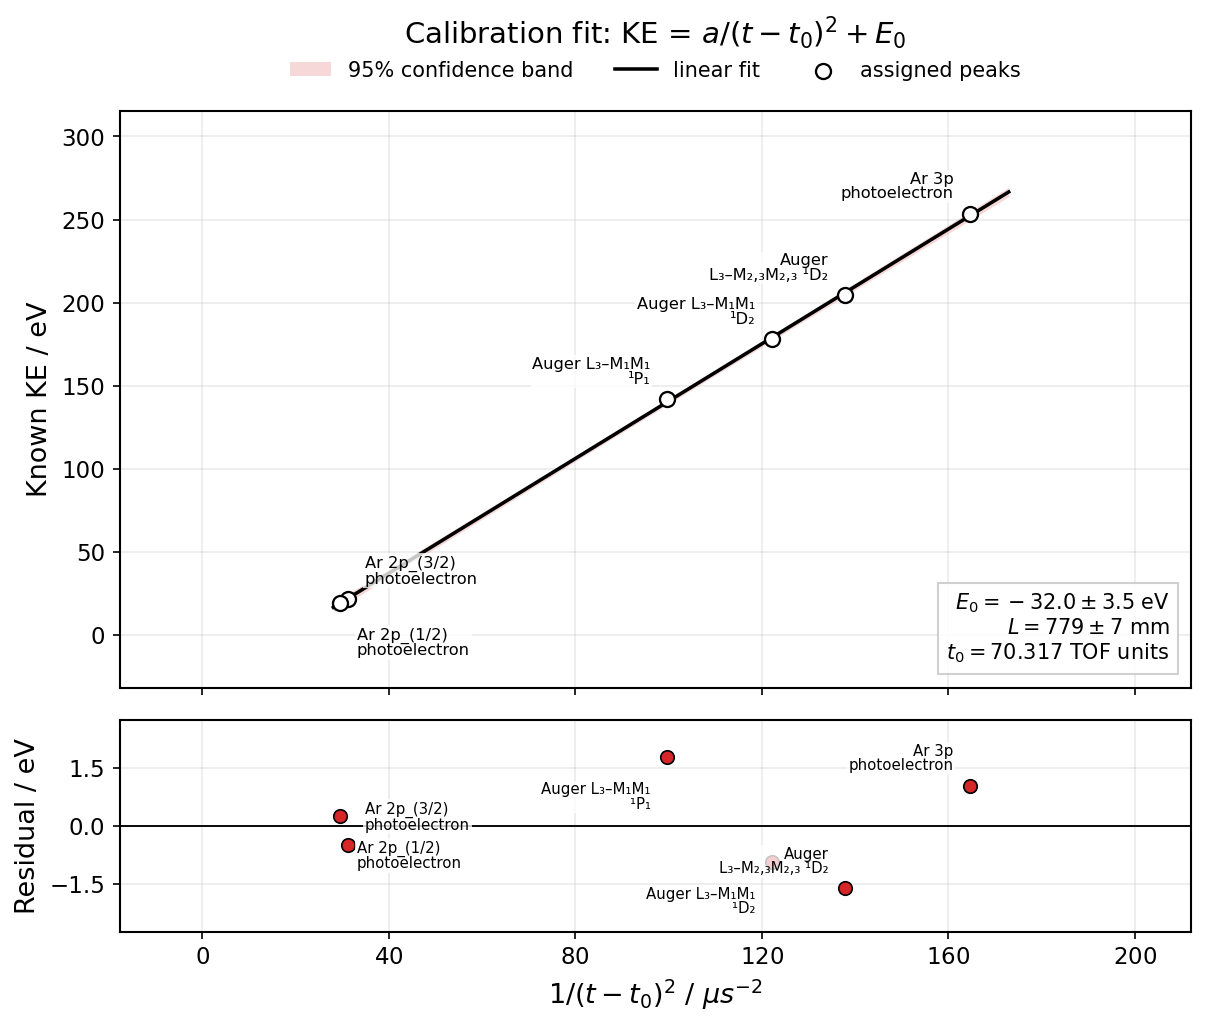

In [17]:
import textwrap
from matplotlib.ticker import MaxNLocator, ScalarFormatter

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "axes.linewidth": 1.0,
})


def label_points_without_overlap(ax, x, y, labels, fontsize=7.8, wrap_width=16):
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    ax_box = ax.get_window_extent(renderer).expanded(0.96, 0.92)
    x_mid = 0.5 * (ax.get_xlim()[0] + ax.get_xlim()[1])

    placed_boxes = []

    for xi, yi, lbl in zip(x, y, labels):
        label = textwrap.fill(str(lbl), width=wrap_width)

        if xi < x_mid:
            offsets = [(8, 6), (8, -12), (12, 0), (8, 18), (8, -24)]
        else:
            offsets = [(-8, 6), (-8, -12), (-12, 0), (-8, 18), (-8, -24)]

        placed = False

        for dx, dy in offsets:
            txt = ax.annotate(
                label,
                xy=(xi, yi),
                xytext=(dx, dy),
                textcoords="offset points",
                fontsize=fontsize,
                linespacing=0.95,
                ha="left" if dx > 0 else "right",
                va="bottom" if dy > 0 else "top",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.78,
                    pad=0.8,
                ),
                clip_on=True,
                zorder=5,
            )

            fig.canvas.draw()
            box = txt.get_window_extent(renderer).expanded(1.04, 1.10)

            inside_axes = (
                box.x0 >= ax_box.x0
                and box.x1 <= ax_box.x1
                and box.y0 >= ax_box.y0
                and box.y1 <= ax_box.y1

            )

            overlaps = any(box.overlaps(old_box) for old_box in placed_boxes)

            if inside_axes and not overlaps:
                placed_boxes.append(box)
                placed = True
                break

            txt.remove()

        if not placed:
            # Fallback: keep the label inside the plot, close to the point.
            dx = 8 if xi < x_mid else -8
            txt = ax.annotate(
                label,
                xy=(xi, yi),
                xytext=(dx, 6),
                textcoords="offset points",
                fontsize=fontsize,
                linespacing=0.95,
                ha="left" if dx > 0 else "right",
                va="bottom",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.78,
                    pad=0.8,
                ),
                clip_on=True,
                zorder=5,
            )
            fig.canvas.draw()
            placed_boxes.append(txt.get_window_extent(renderer).expanded(1.04, 1.10))


fig, (ax_fit, ax_res) = plt.subplots(
    2,
    1,
    figsize=(8.5, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3.0, 1.1]},
)

# Calibration fit
ax_fit.fill_between(
    x_line_us,
    ke_lower,
    ke_upper,
    color="tab:red",
    alpha=0.18,
    linewidth=0,
    label="95% confidence band",
)

ax_fit.plot(
    x_line_us,
    ke_line_us,
    color="black",
    lw=1.7,
    label="linear fit",
)

ax_fit.scatter(
    x_best_us,
    ke_known,
    s=52,
    color="white",
    edgecolor="black",
    linewidth=1.1,
    zorder=4,
    label="assigned peaks",
)

ax_fit.set_title(r"Calibration fit: KE = $a/(t - t_0)^2 + E_0$", pad=32)
ax_fit.set_ylabel("Known KE / eV")
ax_fit.grid(alpha=0.25)

# Put legend above plot so it does not collide with fit info.
ax_fit.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
)

fit_text = (
    rf"$E_0 = {best_E0_us:.1f} \pm {E0_ci95_us:.1f}$ eV" "\n"
    rf"$L = {L_fitted_mm_us:.0f} \pm {L_ci95_mm_us:.0f}$ mm" "\n"
    rf"$t_0 = {best_t0:.3f}$ TOF units"
)

ax_fit.text(
    0.98,
    0.04,
    fit_text,
    transform=ax_fit.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.92),
)

# Residuals
ax_res.axhline(0, color="black", lw=0.9)

ax_res.scatter(
    x_best_us,
    resid_us,
    s=42,
    color="tab:red",
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
)

ax_res.set_xlabel(r"$1/(t - t_0)^2$ / $\mu s^{-2}$")
ax_res.set_ylabel("Residual / eV")
ax_res.grid(alpha=0.25)

# Wider x limits so long labels fit inside the plot area.
x_range = x_best_us.max() - x_best_us.min()
x_pad = 0.35 * x_range
ax_fit.set_xlim(x_best_us.min() - x_pad, x_best_us.max() + x_pad)

y_fit_min = min(ke_known.min(), ke_lower.min())
y_fit_max = max(ke_known.max(), ke_upper.max())
y_fit_pad = 0.18 * (y_fit_max - y_fit_min)
ax_fit.set_ylim(y_fit_min - y_fit_pad, y_fit_max + y_fit_pad)

res_abs = max(abs(resid_us.min()), abs(resid_us.max()))
ax_res.set_ylim(-1.55 * res_abs, 1.55 * res_abs)

# Axis formatting
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 3))
ax_res.xaxis.set_major_formatter(formatter)
ax_res.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax_res.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Full black boundaries
for ax in (ax_fit, ax_res):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)

# Labels added after limits are fixed.
label_points_without_overlap(ax_fit, x_best_us, ke_known, labels, fontsize=7.8, wrap_width=16)
label_points_without_overlap(ax_res, x_best_us, resid_us, labels, fontsize=7.2, wrap_width=16)

fig.subplots_adjust(
    left=0.13,
    right=0.97,
    top=0.88,
    bottom=0.12,
    hspace=0.08,
)

# Uncomment if running on a remote server without figure display.
# fig.savefig("tof_calibration_fit_residuals_clean.png", dpi=600, bbox_inches="tight")
# fig.savefig("tof_calibration_fit_residuals_clean.pdf", bbox_inches="tight")

plt.show()

## Compare Raw and t0-Corrected Axes

Print the raw `1/TOF^2` coordinates beside the corrected `1/(TOF - t0)^2` coordinates for each assigned line. This is a quick numerical sanity check for the transformed x-axis used in the fit figures.


In [18]:
# Compare raw and t0-corrected 1/TOF^2 axes in 1/us^2.

TOF_UNIT_US = 1e-4  # 100 ps = 1e-4 us

print(f"{'label':>32} {'TOF':>10} {'KE/eV':>10} {'x raw':>12} {'x t-t0':>12}")
print("-" * 82)

for t, ke, lbl in ASSIGNMENTS:
    t_raw_us = t * TOF_UNIT_US
    t_corr_us = (t - best_t0) * TOF_UNIT_US

    x_raw = 1.0 / t_raw_us**2
    x_corr = 1.0 / t_corr_us**2

    print(f"{lbl:>32} {t:10.3f} {ke:10.3f} {x_raw:12.3f} {x_corr:12.3f}")

                           label        TOF      KE/eV        x raw       x t-t0
----------------------------------------------------------------------------------
             Ar 3p photoelectron    849.500    253.400      138.571      164.710
           Auger L₃–M₂,₃M₂,₃ ¹D₂    921.800    204.500      117.686      137.927
               Auger L₃–M₁M₁ ¹D₂    975.000    178.000      105.194      122.182
               Auger L₃–M₁M₁ ¹P₁   1071.500    142.000       87.099       99.764
       Ar 2p_(3/2) photoelectron   1856.500     21.600       29.014       31.344
       Ar 2p_(1/2) photoelectron   1907.500     19.400       27.483       29.628


## Apply Calibration to the Ar Spectrum

Convert the background-subtracted Ar spectrum from TOF to kinetic energy. The Jacobian correction converts counts per TOF bin into a counts-per-eV density before plotting the calibrated spectrum.


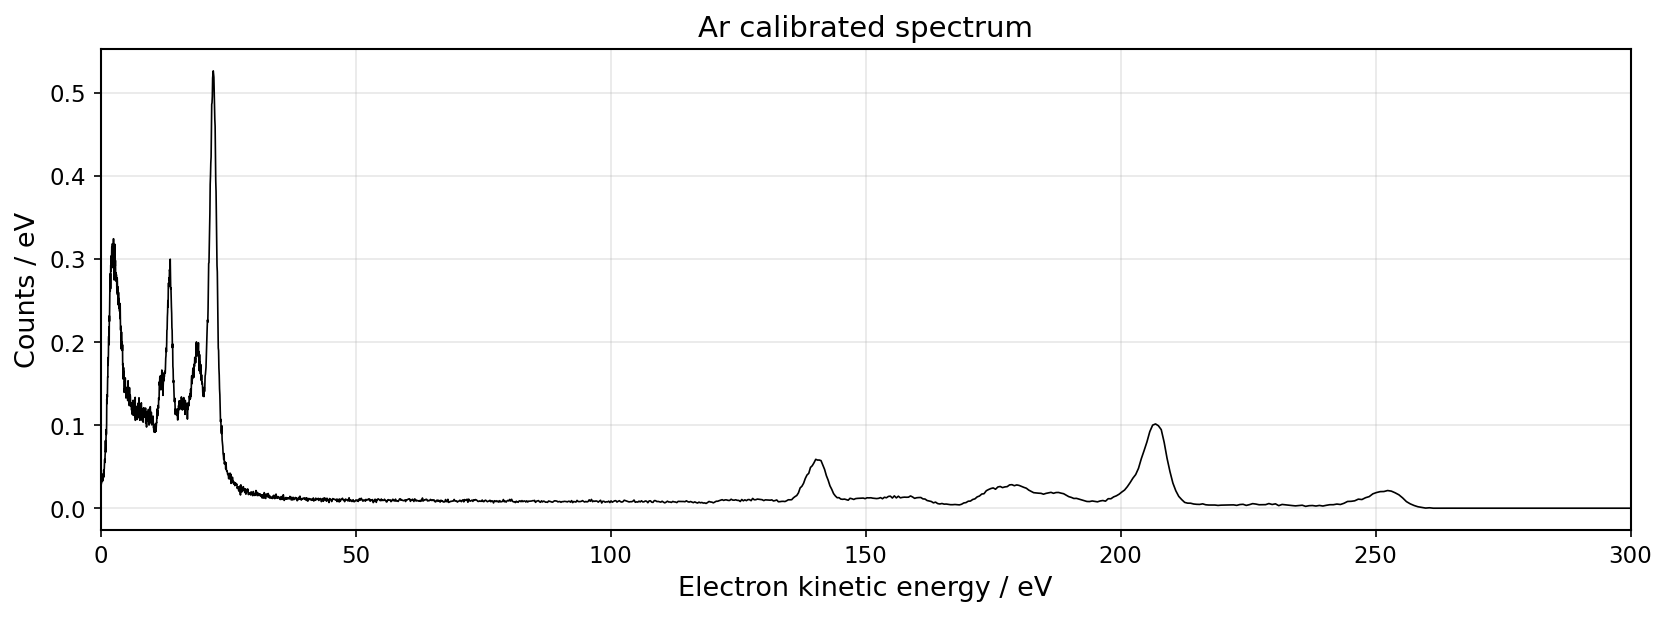

In [19]:
# Apply the new t0-scan calibration to the current TOF spectrum.

ke_axis = KE_from_TOF(tof_cent)

dke_dt = np.gradient(ke_axis, tof_cent)

with np.errstate(divide="ignore", invalid="ignore"):
    spec_ke = ar_sub / np.abs(dke_dt)

valid = (
    np.isfinite(ke_axis)
    & np.isfinite(spec_ke)
    & (ke_axis > 0)
)

order = np.argsort(ke_axis[valid])

ke_plot = ke_axis[valid][order]
spec_plot = spec_ke[valid][order]

fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)

ax.plot(ke_plot, spec_plot, lw=0.8, color="k")

# for _, ke, lbl in ASSIGNMENTS:
#     ax.axvline(ke, color="r", lw=0.7, ls="--")
#     ax.annotate(lbl, (ke, ax.get_ylim()[1]), rotation=90, va="top", ha="right", fontsize=8)

ax.set_xlabel("Electron kinetic energy / eV")
ax.set_ylabel("Counts / eV")
ax.set_title("Ar calibrated spectrum")
ax.grid(alpha=0.3)

#ax.axvline(140)

ax.set_xlim(0,300)

plt.show()

## Load Photon-Energy Scan Spectra

Loop over the glycine wavelength-scan files, load each available incident-energy point, and build a stack of averaged eTOF spectra using the same signal-bunch window and binning.


In [20]:
SCAN_ENERGIES = np.arange(270.0, 282.0 + 0.25, 0.5)

loaded_energies = []
spectra = []

for incident_e in SCAN_ENERGIES:
    path = config.COMBINED_DIR / f"glycine_WL_scan_{incident_e:.1f}eV.h5"

    if not path.exists():
        print(f"Missing: {path.name}")
        continue

    data = load_data(str(path), config=1)

    spectrum, n_shots, total_gmd = average_etof(
        data,
        SIGNAL_BUNCH_RANGE,
        tof_edges,
        normalise="per_shot",
    )

    loaded_energies.append(incident_e)
    spectra.append(spectrum)

    print(f"{incident_e:.1f} eV: {n_shots:,} shots")

loaded_energies = np.asarray(loaded_energies)
spectra = np.asarray(spectra)

if spectra.size == 0:
    raise RuntimeError("No scan files were loaded.")

print(f"Loaded spectra: {spectra.shape}")

270.0 eV: 89,970 shots
270.5 eV: 90,030 shots
271.0 eV: 90,000 shots
271.5 eV: 90,060 shots
272.0 eV: 90,000 shots
272.5 eV: 89,970 shots
273.0 eV: 90,000 shots
273.5 eV: 89,970 shots
274.0 eV: 90,060 shots
274.5 eV: 90,030 shots
275.0 eV: 90,030 shots
275.5 eV: 90,030 shots
276.0 eV: 90,000 shots
276.5 eV: 90,030 shots
277.0 eV: 89,970 shots
277.5 eV: 89,940 shots
278.0 eV: 90,030 shots
278.5 eV: 89,970 shots
279.0 eV: 90,060 shots
279.5 eV: 90,000 shots
280.0 eV: 90,000 shots
280.5 eV: 90,030 shots
281.0 eV: 89,940 shots
281.5 eV: 90,000 shots
282.0 eV: 89,970 shots
Loaded spectra: (25, 4000)


## Convert Scan Maps from TOF to KE

Apply the t0-scan calibration to the scan stack, convert TOF-bin counts to counts per eV, and plot incident photon energy against both raw eTOF and calibrated electron kinetic energy.


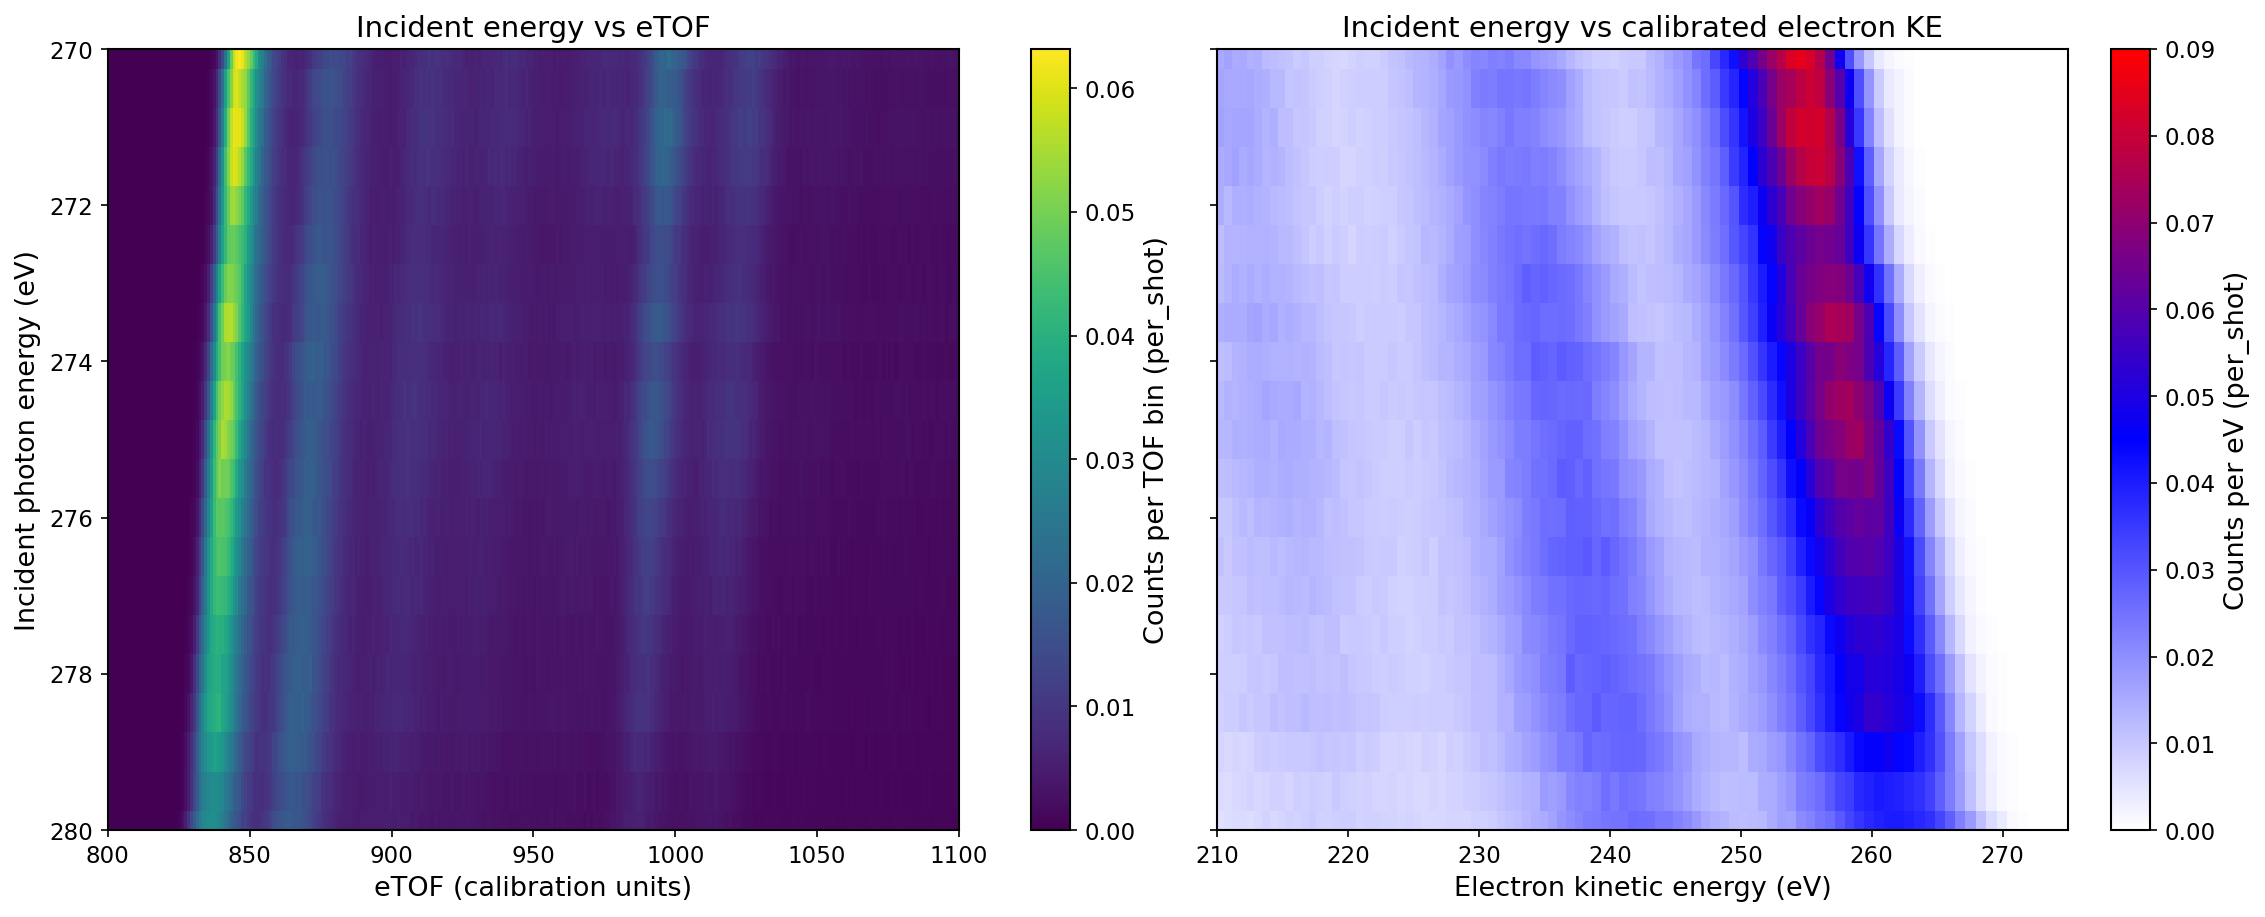

In [21]:
def centres_to_edges(x):
    x = np.asarray(x, dtype=float)

    if x.size == 1:
        return np.array([x[0] - 0.25, x[0] + 0.25])

    mid = 0.5 * (x[:-1] + x[1:])
    return np.concatenate([
        [x[0] - 0.5 * (x[1] - x[0])],
        mid,
        [x[-1] + 0.5 * (x[-1] - x[-2])],
    ])


incident_edges = centres_to_edges(loaded_energies)

# Use the new t0-scan calibration:
#   KE = best_slope / (t - best_t0)^2 + best_E0
#
# This assumes you already ran the t0-scan cell and therefore have:
#   best_t0, best_slope, best_E0
# or the function:
#   KE_from_TOF(t)

if "KE_from_TOF" not in globals():
    def KE_from_TOF(t):
        t = np.asarray(t, dtype=float)

        with np.errstate(divide="ignore", invalid="ignore"):
            ke = best_slope / (t - best_t0)**2 + best_E0

        return np.where(t > best_t0, ke, np.nan)


# Apply calibration to TOF bin edges.
ke_all_edges = KE_from_TOF(tof_edges)

valid_bins = (
    np.isfinite(ke_all_edges[:-1])
    & np.isfinite(ke_all_edges[1:])
    & (ke_all_edges[:-1] > 0)
    & (ke_all_edges[1:] > 0)
)

idx = np.flatnonzero(valid_bins)

if idx.size == 0:
    raise RuntimeError("No valid TOF bins after KE calibration. Check best_t0 / tof_edges.")

# Retain the largest contiguous valid section.
split_at = np.where(np.diff(idx) != 1)[0] + 1
groups = np.split(idx, split_at)
idx = max(groups, key=len)

ke_edges = ke_all_edges[idx[0] : idx[-1] + 2]
spectra_ke = spectra[:, idx]

# Convert counts per TOF bin to counts per eV using bin widths.
dke = np.diff(ke_edges)

with np.errstate(divide="ignore", invalid="ignore"):
    spectra_ke = spectra_ke / np.abs(dke)[None, :]

# Ensure increasing kinetic energy on the x-axis.
if ke_edges[0] > ke_edges[-1]:
    ke_edges = ke_edges[::-1]
    spectra_ke = spectra_ke[:, ::-1]

fig, (ax_tof, ax_ke) = plt.subplots(
    1, 2,
    figsize=(15, 6),
    sharey=True,
    constrained_layout=True,
)

p1 = ax_tof.pcolormesh(
    tof_edges,
    incident_edges,
    spectra,
    shading="auto",
    cmap="viridis",
)

fig.colorbar(p1, ax=ax_tof, label=f"Counts per TOF bin ({NORMALISE})")

ax_tof.set(
    xlabel="eTOF (calibration units)",
    ylabel="Incident photon energy (eV)",
    title="Incident energy vs eTOF",
)

p2 = ax_ke.pcolormesh(
    ke_edges,
    incident_edges,
    spectra_ke,
    shading="auto",
    cmap=w_b_r,
    vmax=0.09,
)

fig.colorbar(p2, ax=ax_ke, label=f"Counts per eV ({NORMALISE})")

ax_ke.set(
    xlabel="Electron kinetic energy (eV)",
    title="Incident energy vs calibrated electron KE",
)

ax_tof.set_xlim(800, 1100)
ax_ke.set_xlim(210, 275)

ax_tof.set_ylim(280, 270)

plt.show()

## Save Calibration JSON

Persist the t0-scan calibration parameters, fit quality, peak assignments, optional metadata, and fixed-`t0` uncertainty estimates to a JSON file for reuse by other notebooks or scripts.


In [32]:
# Save the t0-scan eTOF calibration to JSON,
# including fixed-t0 linear-fit uncertainty estimates if available.

from pathlib import Path
import json
import numpy as np

CALIB_PATH = Path("/home/mmanresa/GLYCINE/etof_energy_calibration_t0_scan.json")
# Example:
# CALIB_PATH = Path(r"C:\Users\mmm120\Desktop\etof_energy_calibration_t0_scan.json")
# CALIB_PATH = Path(_REPO_ROOT) / "analysis" / "post" / "calibration" / "etof_energy_calibration_t0_scan.json"

CALIB_PATH.parent.mkdir(parents=True, exist_ok=True)

calib = {
    "model": "KE_eV = slope / (tof - t0)**2 + E0",
    "tof_units": "100 ps",
    "tof_unit_seconds": float(TOF_UNIT_SECONDS),

    "t0_tof_units": float(best_t0),
    "slope_eV_tof_unit2": float(best_slope),
    "E0_eV": float(best_E0),

    "effective_length_m": float(L_fitted_m) if "L_fitted_m" in globals() else None,
    "effective_length_mm": float(L_fitted_mm) if "L_fitted_mm" in globals() else None,

    "fit_quality": {
        "r2": float(best_r2),
        "rmse_eV": float(best_rmse),
    },

    "t0_scan": {
        "t0_min": float(t0_min),
        "t0_max": float(t0_max),
        "n_steps": int(T0_SCAN_STEPS),
    },

    "assignments": [
        {
            "tof": float(t),
            "known_ke_eV": float(ke),
            "label": str(lbl),
            "predicted_ke_eV": float(pred),
            "residual_eV": float(diff),
        }
        for (t, ke, lbl), pred, diff in zip(ASSIGNMENTS, ke_pred_best, resid_best)
    ],
}

# Add uncertainty estimates from the confidence-band cell, if available.
uncertainty_vars = [
    "n",
    "p",
    "dof",
    "sse",
    "mse",
    "s_err",
    "x_mean",
    "Sxx",
    "tcrit",
    "slope_se",
    "E0_se",
    "slope_ci95",
    "E0_ci95",
    "L_mm",
    "L_se_mm",
    "L_ci95_mm",
]

if all(var in globals() for var in ["slope_se", "E0_se", "slope_ci95", "E0_ci95", "L_ci95_mm"]):
    calib["uncertainty_fixed_t0"] = {
        "description": (
            "Uncertainties from ordinary least-squares fit of "
            "KE = slope*x + E0 at fixed best_t0. "
            "Does not include uncertainty from the outer t0 scan."
        ),
        "confidence_level": 0.95,
        "slope_standard_error": float(slope_se),
        "slope_ci95_half_width": float(slope_ci95),
        "E0_standard_error_eV": float(E0_se),
        "E0_ci95_half_width_eV": float(E0_ci95),
        "L_mm": float(L_mm),
        "L_standard_error_mm": float(L_se_mm),
        "L_ci95_half_width_mm": float(L_ci95_mm),
        "fit_standard_error_eV": float(s_err),
        "degrees_of_freedom": int(dof),
        "t_critical_95": float(tcrit),
    }

    # Optional extra diagnostics if defined.
    for var in uncertainty_vars:
        if var in globals():
            value = globals()[var]
            if isinstance(value, np.generic):
                value = value.item()
            if np.isscalar(value):
                calib["uncertainty_fixed_t0"][var] = float(value) if not isinstance(value, int) else int(value)

else:
    print("Warning: uncertainty variables not found; saving calibration without uncertainty block.")
    print("Run the confidence-band/uncertainty cell first if you want uncertainties saved.")

# Optional metadata, only saved if these variables exist.
optional_fields = {
    "run_ar": "RUN_AR",
    "run_bg": "RUN_BG",
    "photon_energy_eV": "PHOTON_ENERGY_EV",
    "normalisation": "NORMALISE",
}

for json_key, var_name in optional_fields.items():
    if var_name in globals():
        value = globals()[var_name]

        if isinstance(value, np.generic):
            value = value.item()

        calib[json_key] = value

if "SIGNAL_BUNCH_RANGE" in globals():
    calib["signal_bunch_range"] = list(SIGNAL_BUNCH_RANGE)

with open(CALIB_PATH, "w", encoding="utf-8") as fh:
    json.dump(calib, fh, indent=2, ensure_ascii=False)

print(f"Saved calibration to:")
print(CALIB_PATH.resolve())

if "uncertainty_fixed_t0" in calib:
    print()
    print("Saved uncertainty estimates:")
    print(f"  E0 = {best_E0:.3f} ± {E0_ci95:.3f} eV  (95% CI, fixed t0)")
    print(f"  L  = {L_mm:.2f} ± {L_ci95_mm:.2f} mm  (95% CI, fixed t0)")

Saved calibration to:
/home/mmanresa/GLYCINE/etof_energy_calibration_t0_scan.json

Saved uncertainty estimates:
  E0 = -32.016 ± 3.454 eV  (95% CI, fixed t0)
  L  = 779.32 ± 7.07 mm  (95% CI, fixed t0)


## Reload and Reuse Saved Calibration

Load the saved JSON calibration, reconstruct `KE_from_TOF`, and print the stored fit quality and uncertainty summary. This verifies that the saved file is sufficient to reproduce the conversion elsewhere.


In [35]:
from pathlib import Path
import json
import numpy as np

CALIB_PATH = Path("etof_energy_calibration_t0_scan.json")

with open(CALIB_PATH, "r", encoding="utf-8") as fh:
    calib = json.load(fh)

best_t0 = calib["t0_tof_units"]
best_slope = calib["slope_eV_tof_unit2"]
best_E0 = calib["E0_eV"]

def KE_from_TOF(t):
    t = np.asarray(t, dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        ke = best_slope / (t - best_t0)**2 + best_E0

    return np.where(t > best_t0, ke, np.nan)

tof_to_ke = KE_from_TOF

print("Loaded eTOF calibration:")
print(f"  t0    = {best_t0:.6f} TOF units")
print(f"  slope = {best_slope:.6e} eV * TOF_unit^2")
print(f"  E0    = {best_E0:.6f} eV")

if "effective_length_mm" in calib:
    print(f"  L     = {calib['effective_length_mm']:.2f} mm")

if "fit_quality" in calib:
    print(f"  RMSE  = {calib['fit_quality'].get('rmse_eV', np.nan):.4f} eV")
    print(f"  R²    = {calib['fit_quality'].get('r2', np.nan):.8f}")

if "uncertainty_fixed_t0" in calib:
    unc = calib["uncertainty_fixed_t0"]

    print()
    print("Fixed-t0 uncertainty estimates:")
    print(
        f"  E0 = {best_E0:.3f} ± "
        f"{unc['E0_ci95_half_width_eV']:.3f} eV "
        f"({unc['confidence_level']*100:.0f}% CI)"
    )
    print(
        f"  L  = {unc['L_mm']:.2f} ± "
        f"{unc['L_ci95_half_width_mm']:.2f} mm "
        f"({unc['confidence_level']*100:.0f}% CI)"
    )

Loaded eTOF calibration:
  t0    = 70.317117 TOF units
  slope = 1.726561e+08 eV * TOF_unit^2
  E0    = -32.015747 eV
  L     = 779.32 mm
  RMSE  = 1.1566 eV
  R²    = 0.99982907

Fixed-t0 uncertainty estimates:
  E0 = -32.016 ± 3.454 eV (95% CI)
  L  = 779.32 ± 7.07 mm (95% CI)
